In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
L        = 12
H_SEED   = 42            # fixed Hamiltonian disorder seed
label    = "ps26_lowE"   # product-state IC label (set "" to read legacy ..._chi{chi}.csv)
chi_list = [16, 32, 64, 128, 256, 512, 1024]
t_therm  = 30.0   # late-time window for time-averaging

cmap   = plt.get_cmap('viridis')
colors = {chi: cmap(i / (len(chi_list) - 1)) for i, chi in enumerate(chi_list)}

def conv_filename(chi):
    suffix = f"_seed{H_SEED}_{label}" if label else ""
    return f"results/bond_convergence/n_profile_vs_t_L{L}_chi{chi}{suffix}.csv"

data = {}
for chi in chi_list:
    fname = conv_filename(chi)
    with open(fname) as f:
        comment_lines = [ln for ln in f if ln.startswith('#')]
    # Robust to the two-line header (# params_file then # E0) of the product-state files.
    E0_lines = [ln for ln in comment_lines if ln.strip().startswith('# E0')]
    E0 = float(E0_lines[0].split('=')[1])
    df = pd.read_csv(fname, comment='#')
    data[chi] = dict(
        times     = df['time'].values,
        energy    = df['energy'].values,
        S_mid     = df['S_mid'].values,
        trunc_err = df['trunc_err'].values,
        n_matrix  = np.column_stack([df[f'n_{j+1}'].values for j in range(L)]),
        E0        = E0,
    )
    d = data[chi]
    print(f"chi={chi:5d}:  T_end={d['times'][-1]:.1f}  E0={E0:.6f}  "
          f"S_mid(T)={d['S_mid'][-1]:.4f}  trunc_err(T)={d['trunc_err'][-1]:.2e}")

chi=   16:  T_end=40.0  E0=-0.402180  S_mid(T)=2.5970  trunc_err(T)=8.61e-04
chi=   32:  T_end=40.0  E0=-0.402180  S_mid(T)=3.2989  trunc_err(T)=6.24e-04
chi=   64:  T_end=40.0  E0=-0.402180  S_mid(T)=3.9919  trunc_err(T)=4.59e-04
chi=  128:  T_end=40.0  E0=-0.402180  S_mid(T)=4.6670  trunc_err(T)=2.89e-04
chi=  256:  T_end=40.0  E0=-0.402180  S_mid(T)=5.2605  trunc_err(T)=1.05e-04
chi=  512:  T_end=40.0  E0=-0.402180  S_mid(T)=5.3283  trunc_err(T)=1.71e-05
chi= 1024:  T_end=40.0  E0=-0.402180  S_mid(T)=5.3351  trunc_err(T)=1.22e-15


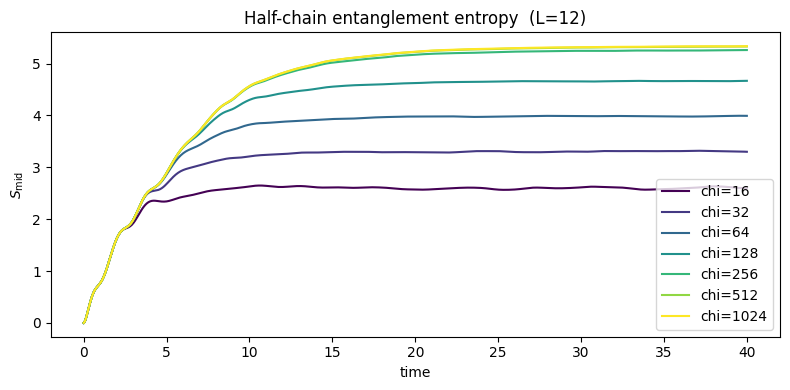

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for chi in chi_list:
    d = data[chi]
    ax.plot(d['times'], d['S_mid'], color=colors[chi], lw=1.5, label=f'chi={chi}')
ax.set_xlabel('time')
ax.set_ylabel(r'$S_{\rm mid}$')
ax.set_title(f'Half-chain entanglement entropy  (L={L})')
ax.legend()
plt.tight_layout()
plt.show()

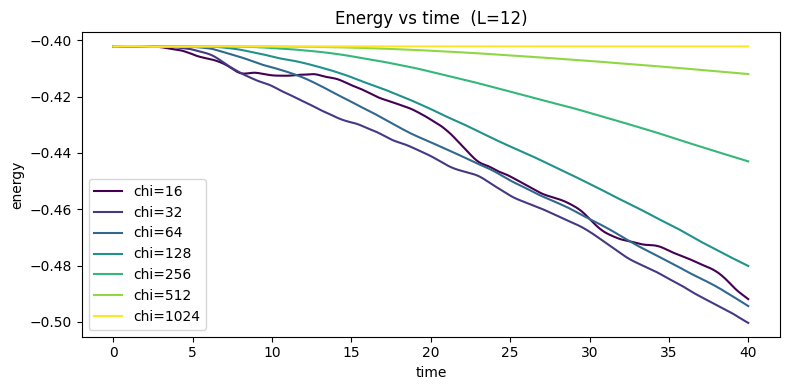

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
for chi in chi_list:
    d = data[chi]
    ax.plot(d['times'], d['energy'], color=colors[chi], lw=1.5, label=f'chi={chi}')
ax.set_xlabel('time')
ax.set_ylabel('energy')
ax.set_title(f'Energy vs time  (L={L})')
ax.legend()
plt.tight_layout()
plt.show()

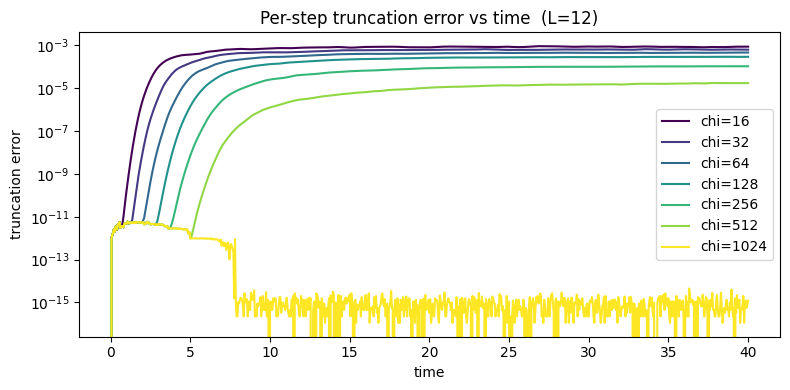

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for chi in chi_list:
    d = data[chi]
    ax.semilogy(d['times'], d['trunc_err'], color=colors[chi], lw=1.5, label=f'chi={chi}')
ax.set_xlabel('time')
ax.set_ylabel('truncation error')
ax.set_title(f'Per-step truncation error vs time  (L={L})')
ax.legend()
plt.tight_layout()
plt.show()

<>:12: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:12: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/2w/lw0n043x0qv9lhtp8kpmwd7c0000gn/T/ipykernel_16038/2845535191.py:12: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  ax.set_title(f'Late-time (t $\geq$ {t_therm}) time-averaged density profile  (L={L})')


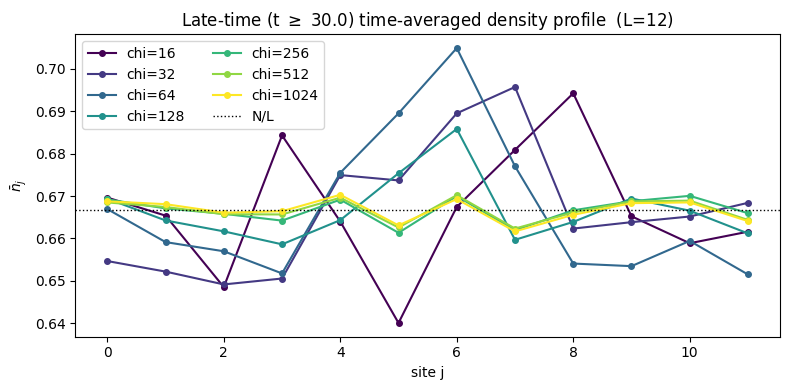

In [6]:
j_arr = np.arange(L)

fig, ax = plt.subplots(figsize=(8, 4))
for chi in chi_list:
    d = data[chi]
    mask  = d['times'] >= t_therm
    n_bar = d['n_matrix'][mask].mean(axis=0)
    ax.plot(j_arr, n_bar, '-o', markersize=4, color=colors[chi], lw=1.5, label=f'chi={chi}')
ax.axhline(8 / L, color='k', linestyle=':', lw=1.0, label='N/L')
ax.set_xlabel('site j')
ax.set_ylabel(r'$\bar{n}_j$')
ax.set_title(f'Late-time (t $\geq$ {t_therm}) time-averaged density profile  (L={L})')
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

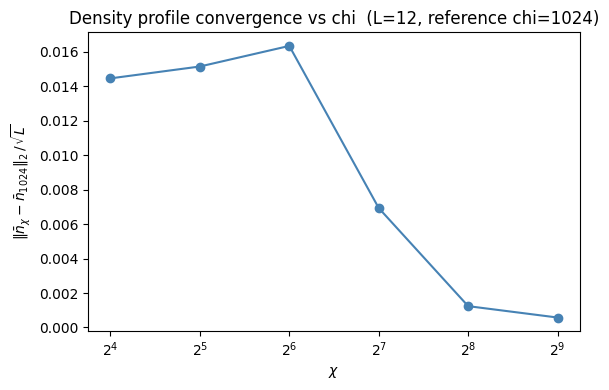

In [7]:
# Convergence error relative to chi=1024
ref_mask = data[1024]['times'] >= t_therm
n_ref    = data[1024]['n_matrix'][ref_mask].mean(axis=0)

chi_vals, errs = [], []
for chi in chi_list[:-1]:
    d    = data[chi]
    mask = d['times'] >= t_therm
    n_bar = d['n_matrix'][mask].mean(axis=0)
    errs.append(np.linalg.norm(n_bar - n_ref) / np.sqrt(L))
    chi_vals.append(chi)

fig, ax = plt.subplots(figsize=(6, 4))
# ax.semilogy(chi_vals, errs, 'o-', color='steelblue')
ax.plot(chi_vals,errs, 'o-', color='steelblue')
ax.set_xscale("log", base = 2)
ax.set_xlabel(r'$\chi$')
ax.set_ylabel(r'$\|\bar{n}_\chi - \bar{n}_{1024}\|_2\,/\,\sqrt{L}$')
ax.set_title(f'Density profile convergence vs chi  (L={L}, reference chi=1024)')
ax.set_xticks(chi_vals)
plt.tight_layout()
plt.show()